# Conceptual Engineering with BERT

This notebook walks through the process of creating all results and figures for the paper:

Haket, N., & Daniels, R. (2025). BERT’s Conceptual Cartography: Mapping the Landscapes of Meaning. Society for Computation in Linguistics, 8(1), Article 1. https://doi.org/10.7275/scil.3145

Further information, files, and datasets can be found on:
 https://github.com/acceleratescience/conceptual-cartography

 This was also the method used for N.Haket's PhD thesis.


#Preliminaries

Install huggingface, adding your token, linking to googledrive, and loading the required packages

In [ ]:
pip install huggingface-hub

In [ ]:
import os

# Replace 'your_huggingface_token' with your actual Hugging Face token
hf_token = '...'

# Set the token as an environment variable
os.environ['...'] = hf_token

# Save the token for use with Hugging Face Hub
from huggingface_hub import HfFolder
HfFolder.save_token(hf_token)

# Verify the token and print user information
from huggingface_hub import HfApi

api = HfApi()
user_info = api.whoami()
print(user_info)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


{'type': 'user', 'id': '6699041eaa500cd99d5ff0d4', 'name': 'NCHaket', 'fullname': 'Nina', 'email': 'nch35@cam.ac.uk', 'emailVerified': True, 'canPay': False, 'periodEnd': None, 'isPro': False, 'avatarUrl': '/avatars/6299f777dd119c163f4bb7345952161f.svg', 'orgs': [], 'auth': {'type': 'access_token', 'accessToken': {'displayName': 'Colab', 'role': 'write', 'createdAt': '2024-07-19T11:18:50.023Z'}}}


In [ ]:
import os
import sys
from google.colab import drive

module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

 # # Mount Google Drive
mount = '/content/gdrive'
print("Colab: mounting Google drive on ", mount)
drive.mount(mount)


Colab: mounting Google drive on  /content/gdrive
Mounted at /content/gdrive


In [ ]:
from google.colab import drive
import os
import torch
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patches as patches
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.model_selection import ParameterGrid
import gspread
from google.colab import auth
from google.auth import default



# # Switch to the directory on the Google Drive you want to use
drive_root = mount + ".lm-conceptual-engineering-main"

# Create drive_root if it doesn't exist
create_drive_root = True
if create_drive_root:
  print("\nColab: making sure ", drive_root, " exists.")
  os.makedirs(drive_root, exist_ok=True)

# Change to the directory
print("\nColab: Changing directory to ", drive_root)
%cd $drive_root



/usr/lib/python3/dist-packages/blinker/base.py:96: SyntaxWarning: invalid escape sequence '\*'
  `sender=` as a single positional argument and any \*\*kwargs that
/usr/lib/python3/dist-packages/blinker/base.py:174: SyntaxWarning: invalid escape sequence '\*'
  `sender=` as a single positional argument and any \*\*kwargs that
/usr/lib/python3/dist-packages/blinker/base.py:242: SyntaxWarning: invalid escape sequence '\*'
  """Emit this signal on behalf of *sender*, passing on \*\*kwargs.



Colab: making sure  /content/gdrive/MyDrive/lm-conceptual-engineering-main  exists.

Colab: Changing directory to  /content/gdrive/MyDrive/lm-conceptual-engineering-main
/content/gdrive/MyDrive/lm-conceptual-engineering-main


In [ ]:
plt.rcParams['text.usetex'] = True
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['xtick.top'] = True
plt.rcParams['ytick.right'] = True

In [ ]:
import multiprocessing
import pickle

import matplotlib.pyplot as plt
import numpy as np
import torch
import yaml
from matplotlib.colors import LogNorm
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.mixture import GaussianMixture
from sklearn.model_selection import ParameterGrid
from tqdm import tqdm

from lm_conceptual_engineering import embedding
from lm_conceptual_engineering.experiment import (
    get_consensus_labels_and_ARI,
    get_embeddings_and_metrics,
    multi_context,
)
from lm_conceptual_engineering.metrics import (
    average_pairwise_cosine_similarity,
    intra_inter_similarity,
    mev,
)



/usr/local/lib/python3.12/dist-packages/torch_xla/experimental/gru.py:113: SyntaxWarning: invalid escape sequence '\_'
  * **h_n**: tensor of shape :math:`(D * \text{num\_layers}, H_{out})` or


In [ ]:
!apt install texlive-fonts-recommended texlive-fonts-extra cm-super dvipng

## Run the target words through BERT
The stage is to think of a list of target words. This is saved in the file `./experiments/wordlist.yaml`.

In [ ]:
with open('.wordlist.yaml', 'r') as f:
    word_list = yaml.safe_load(f)['words']

print(word_list)
print(len(word_list))

['weight', 'pressure', 'electricity', 'temperature', 'energy', 'water', 'planet', 'cancer', 'protein', 'tiger', 'theory', 'system', 'data', 'concept', 'information', 'truth', 'freedom', 'responsibility', 'knowledge', 'duty', 'family', 'marriage', 'education', 'economy', 'exam', 'student', 'friend', 'engineer', 'wife', 'child', 'computer', 'cable', 'wheel', 'hat', 'camera']
35


## Multi-context experiment

Parameters set to the optimal 40 word context window identified by Haket & Daniels, in order to speed up running time. In the paper Haket & Daniels we ran this from 1 to 98 words, identifying 40 as the optimal, so this is what I used for the purposes of this thesis.

In [ ]:
import concurrent.futures

multicontext_params = {
    'word_list' : word_list,
    'param_grid' : {
        'n_clusters': np.arange(2,10),
        'n_components': np.arange(2, 10)
    },
    'context_windows' : list(range(39, 41))
}

results = multi_context(multicontext_params)


Running...: 100%|██████████| 35/35 [2:00:34<00:00, 206.71s/it]


In [ ]:
with open('./results.pkl', 'rb') as f:
    results = pickle.load(f)

context_windows = list(range(39,41))

## Context Window

The analysis iterates over a list of target words (word_list) and evaluates the quality of clustering across multiple context window sizes, PCA dimensionality reductions, and GMM cluster counts. It uses the silhouette score as the primary performance metric, capturing how well embeddings form distinct semantic clusters.

The results of these model runs are aggregated and visualised to determine optimal parameter settings for downstream semantic interpretation tasks.

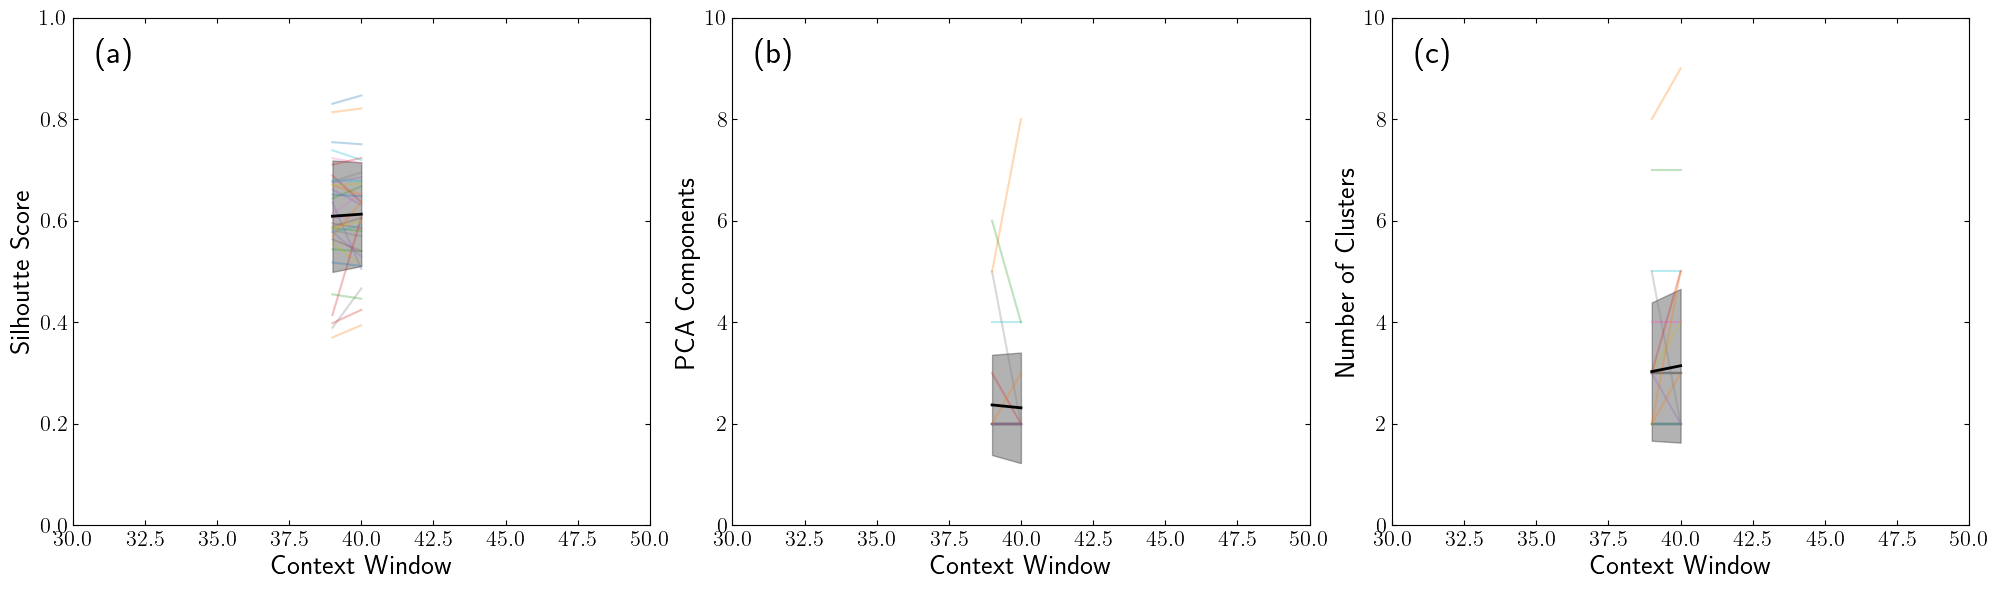

In [ ]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 6))

mean_scores = np.zeros((35, len(context_windows)))
mean_pca_components = np.zeros((35, len(context_windows)))
mean_n_components = np.zeros((35, len(context_windows)))

for i, keyword in enumerate(word_list):
    best_scores = [results[keyword][context_window]['best_score'] for context_window in context_windows]
    mean_scores[i, :] = best_scores
    ax1.plot(context_windows, best_scores, label=keyword, alpha=0.3)

    pca_components = [results[keyword][context_window]['best_params']['n_components'] for context_window in context_windows]
    mean_pca_components[i, :] = pca_components
    ax2.plot(context_windows, pca_components, label=keyword, alpha=0.3)

    n_components = [results[keyword][context_window]['best_params']['n_clusters'] for context_window in context_windows]
    mean_n_components[i, :] = n_components
    ax3.plot(context_windows, n_components, label=keyword, alpha=0.3)

ax1.plot(context_windows, mean_scores.mean(axis=0), label='mean', color='k', lw=2)
ax1.fill_between(context_windows, mean_scores.mean(axis=0) - mean_scores.std(axis=0), mean_scores.mean(axis=0) + mean_scores.std(axis=0), color='k', alpha=0.3)
ax1.set_ylim(0, 1)
ax1.set_ylabel('Silhoutte Score', fontsize=20)

ax2.plot(context_windows, mean_pca_components.mean(axis=0), label='mean', color='k', lw=2)
ax2.fill_between(context_windows, mean_pca_components.mean(axis=0) - mean_pca_components.std(axis=0), mean_pca_components.mean(axis=0) + mean_pca_components.std(axis=0), color='k', alpha=0.3)
ax2.set_ylim(0, 10)
ax2.set_ylabel('PCA Components', fontsize=20)

ax3.plot(context_windows, mean_n_components.mean(axis=0), label='mean', color='k', lw=2)
ax3.fill_between(context_windows, mean_n_components.mean(axis=0) - mean_n_components.std(axis=0), mean_n_components.mean(axis=0) + mean_n_components.std(axis=0), color='k', alpha=0.3)
ax3.set_ylim(0, 10)
ax3.set_ylabel('Number of Clusters', fontsize=20)

for ax in [ax1, ax2, ax3]:
    ax.set_xlabel('Context Window', fontsize=20)
    # ax.grid()
    ax.set_xlim(30, 50)
    # set tick sizes
    ax.tick_params(axis='both', which='major', labelsize=16)

ax1.text(0.04, 0.96, '(a)', transform=ax1.transAxes, fontsize=24, va='top')
ax2.text(0.04, 0.96, '(b)', transform=ax2.transAxes, fontsize=24, va='top')
ax3.text(0.04, 0.96, '(c)', transform=ax3.transAxes, fontsize=24, va='top')

plt.tight_layout()
plt.savefig('.assets/imgs/context_window.png', dpi=240)
plt.show()

In [ ]:
best_scores = []
best_components = []
best_clusters = []
for word in word_list:
    best_scores.append(results[word][40]['best_score'])
    best_components.append(results[word][40]['best_params']['n_components'])
    best_clusters.append(results[word][40]['best_params']['n_clusters'])

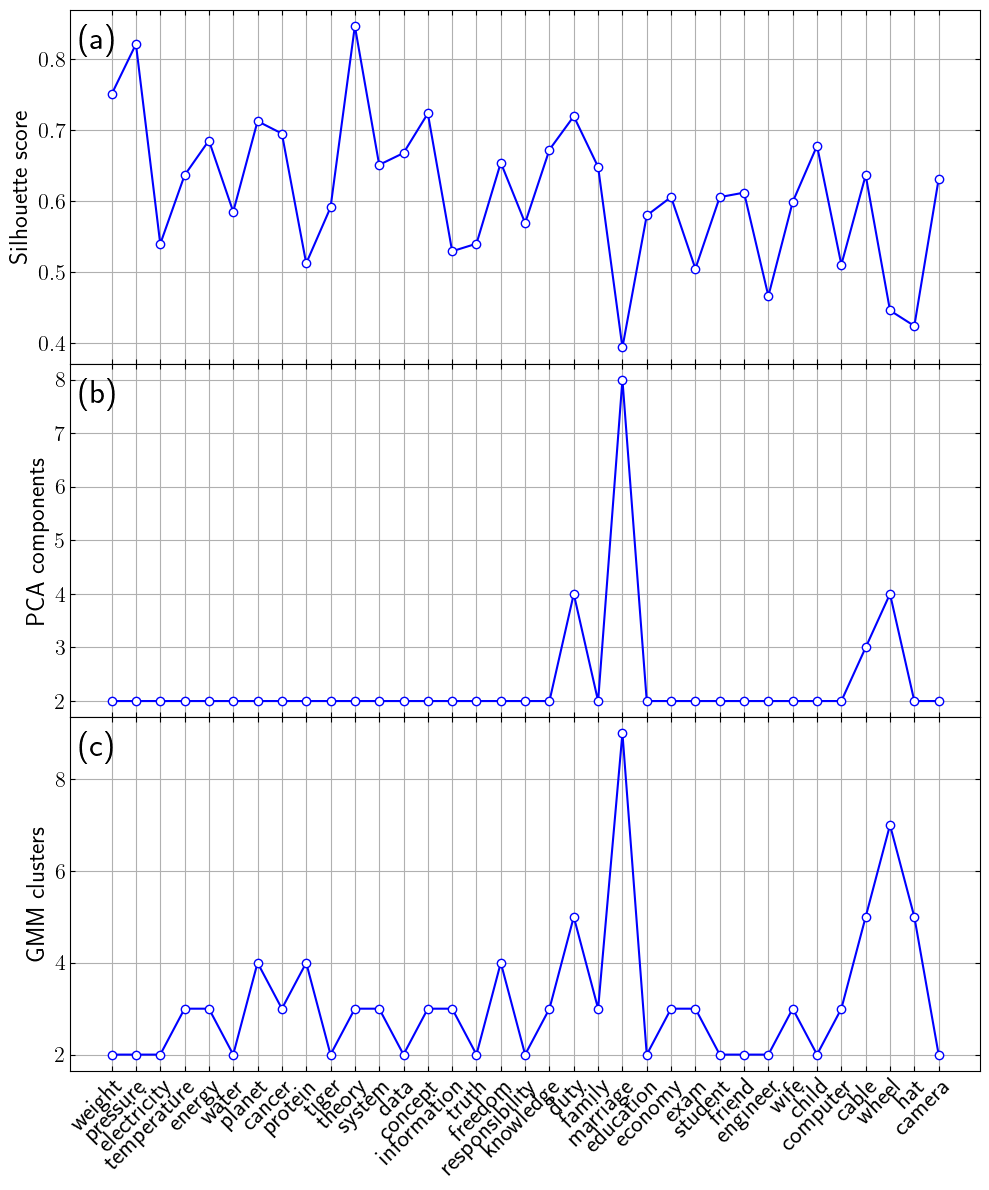

In [ ]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 12), sharex=True)
ax1.plot(word_list, best_scores, marker='o', c='b', mec='b', mfc='w')
ax1.set_ylabel('Silhouette score', fontsize=18)
ax1.grid()
ax1.text(0.01, 0.96, '(a)', transform=ax1.transAxes, fontsize=24, va='top')

ax2.plot(word_list, best_components, marker='o', c='b', mec='b', mfc='w')
ax2.set_ylabel('PCA components', fontsize=18)
ax2.grid()
ax2.text(0.01, 0.96, '(b)', transform=ax2.transAxes, fontsize=24, va='top')

ax3.plot(word_list, best_clusters, marker='o', c='b', mec='b', mfc='w')
ax3.set_ylabel('GMM clusters', fontsize=18)
ax3.grid()
ax3.text(0.01, 0.96, '(c)', transform=ax3.transAxes, fontsize=24, va='top')
ax1.tick_params(axis='both', which='major', labelsize=16)
ax2.tick_params(axis='both', which='major', labelsize=16)
ax3.tick_params(axis='both', which='major', labelsize=16)

plt.xticks(rotation=45, ha='right', rotation_mode='anchor', fontsize=18)
plt.tight_layout()
# make the vertical separation between subplots 0
plt.subplots_adjust(hspace=0)
plt.savefig('.assets/imgs/word_silhouette.png', dpi=240)

##Encode using BERT

Creating and saving BERT embeddings and clustering metrics for the target words with a 40-token context window to avoid rerunning the computation.

In [ ]:
#note to self: done this and saved it so you don't need to run again, just load it from drive
params = {
        'model_name': 'bert-large-uncased',
        'target_word': word_list,
        'context_window': 40,
        'text_folder': './data/bnc_dataset/', # remove first dot depending on where you are running this notebook/storing the data...
        'output_folder': './experiments/',
    }

experiment_data_all = get_embeddings_and_metrics(params, dump=True, verbose=True)

Processing embeddings for target word (1 of 35) : 'weight'...


100%|██████████| 1251/1251 [02:16<00:00,  9.16it/s]


Processing embeddings for target word (2 of 35) : 'pressure'...


100%|██████████| 1251/1251 [01:54<00:00, 10.92it/s]


Processing embeddings for target word (3 of 35) : 'electricity'...


...

Processing embeddings for target word (34 of 35) : 'hat'...


100%|██████████| 1251/1251 [02:05<00:00,  9.97it/s]


Processing embeddings for target word (35 of 35) : 'camera'...


100%|██████████| 1251/1251 [01:50<00:00, 11.35it/s]


Dumping data...
Data dumped!
Experiment complete!


## Stability, MEV and Similarity

This script loads precomputed clustering results and BERT embeddings for a set of target words, computes consensus labels and ARI (Adjusted Rand Index) scores for both optimal and 2D-forced PCA dimensionality, stores intra- and inter-cluster similarity measures, and updates the experiment_data_all object with these metrics. All results are saved to pickle files (ARI_optimal.pkl and ARI_2d.pkl) for later use.

In [ ]:
with open('./results.pkl', 'rb') as f:
    results = pickle.load(f)

experiment_data_all = torch.load(
    '.bert-large-uncased_40_bnc_dataset.pt',
    weights_only=False
)

context_windows = list(range(39,41))

In [ ]:
import pickle
from tqdm import tqdm

# Initialize a dictionary to store results for all keywords
all_results = {}

# Loop over each keyword
for keyword in tqdm(word_list):  # Replace keywords with your actual list of keywords
    # Retrieve optimal parameters for the keyword
    optimal_params = results[keyword][40]['best_params']

    # Get the consensus labels and ARI scores
    X_pca, ari_scores, consensus_labels, Zs, intra_similarity, inter_similarity = get_consensus_labels_and_ARI(
        keyword,
        experiment_data_all,
        optimal_params,
        forced_components=False
    )

    # Store the results in the dictionary
    all_results[keyword] = {
        'X_pca': X_pca,
        'ari_scores': ari_scores,
        'consensus_labels': consensus_labels,
        'intra_similarity': intra_similarity,
        'inter_similarity': inter_similarity
    }

# Save all results to a single pickle file
with open('./ARI_optimal.pkl', 'wb') as f:
    pickle.dump(all_results, f)

print("All results have been saved to 'all_results_optimal.pkl'")



100%|██████████| 35/35 [4:01:19<00:00, 413.69s/it]


All results have been saved to 'all_results_optimal.pkl'


In [ ]:
import pickle
import numpy as np

# Load the results from the pickle file
with open('./ARI_optimal.pkl', 'rb') as f:
    all_results = pickle.load(f)

# Update experiment_data_all with the results
for keyword, result in all_results.items():
    X_pca = result['X_pca']
    ari_scores = result['ari_scores']
    consensus_labels = result['consensus_labels']
    intra_similarity = result['intra_similarity']
    inter_similarity = result['inter_similarity']

    # Update the experiment_data_all object
    experiment_data_all.results_by_word[keyword].consensus_labels_optimal = consensus_labels
    experiment_data_all.results_by_word[keyword].ari_mean_optimal = np.mean(ari_scores)
    experiment_data_all.results_by_word[keyword].ari_std_optimal = np.std(ari_scores)
    experiment_data_all.results_by_word[keyword].X_pca = X_pca
    experiment_data_all.results_by_word[keyword].intra_similarity_optimal = intra_similarity
    experiment_data_all.results_by_word[keyword].inter_similarity_optimal = inter_similarity


In [ ]:
# Initialize a dictionary to store results for all keywords
all_results = {}

# Loop over each keyword
for keyword in tqdm(word_list):  # Replace keywords with your actual list of keywords
    # Retrieve optimal parameters for the keyword
    optimal_params = results[keyword][40]['best_params']

    # Get the consensus labels and ARI scores
    X_pca, ari_scores, consensus_labels, Zs, intra_similarity, inter_similarity = get_consensus_labels_and_ARI(
        keyword,
        experiment_data_all,
        optimal_params,
        forced_components=2
    )

    # Store the results in the dictionary
    all_results[keyword] = {
        'X_pca': X_pca,
        'ari_scores': ari_scores,
        'consensus_labels': consensus_labels,
        'Zs': Zs,
        'intra_similarity': intra_similarity,
        'inter_similarity': inter_similarity
    }

# Save all results to a single pickle file
with open('./ARI_2d.pkl', 'wb') as f:
    pickle.dump(all_results, f)

print("All results have been saved to 'ARI_2d.pkl'")

100%|██████████| 35/35 [4:01:57<00:00, 414.78s/it]


All results have been saved to 'ARI_2d.pkl'


In [ ]:
# Load the results from the pickle file
with open('./ARI_2d.pkl', 'rb') as f:
    all_results2D = pickle.load(f)

# Update experiment_data_all with the results
for keyword, result in all_results2D.items():
    X_pca2 = result['X_pca']
    ari_scores2 = result['ari_scores']
    consensus_labels2 = result['consensus_labels']
    Zs = result['Zs']  # Corrected variable name
    intra_similarity2 = result['intra_similarity']
    inter_similarity2 = result['inter_similarity']

    experiment_data_all.results_by_word[keyword].consensus_labels_2D = consensus_labels2
    experiment_data_all.results_by_word[keyword].ari_mean_2D = np.mean(ari_scores2)
    experiment_data_all.results_by_word[keyword].ari_std_2D = np.std(ari_scores2)
    experiment_data_all.results_by_word[keyword].Zs = Zs
    experiment_data_all.results_by_word[keyword].intra_similarity_2D = intra_similarity2
    experiment_data_all.results_by_word[keyword].inter_similarity_2D = inter_similarity2


# Plot the results

This script computes anisotropic similarity and MEV metrics for a list of target words using BERT embeddings, extracts average pairwise cosine similarity and MEV per word, and visualizes these alongside intra- and inter-cluster similarities and Adjusted Rand Index (ARI) scores for both optimal and 2D PCA configurations. Results are plotted in multi-panel figures (ari_comparison.png and metricsimage.png) and saved locally, with one figure also set up for browser download.

In [ ]:
from lm_conceptual_engineering.metrics import anisotropic_sim_mev

anisotropic_sim, anisotropic_mev, experiment_data = anisotropic_sim_mev(experiment_data_all, word_list)

average_sims = [experiment_data_all.results_by_word[keyword].metrics.average_pairwise_cosine_similarity for keyword in word_list]
average_mevs = [experiment_data_all.results_by_word[keyword].metrics.mev for keyword in word_list]

aris_optimal = [experiment_data_all.results_by_word[keyword].ari_mean_optimal for keyword in word_list]
stds_optimal = [experiment_data_all.results_by_word[keyword].ari_std_optimal for keyword in word_list]

aris_2D = [experiment_data_all.results_by_word[keyword].ari_mean_2D for keyword in word_list]
stds_2D = [experiment_data_all.results_by_word[keyword].ari_std_2D for keyword in word_list]

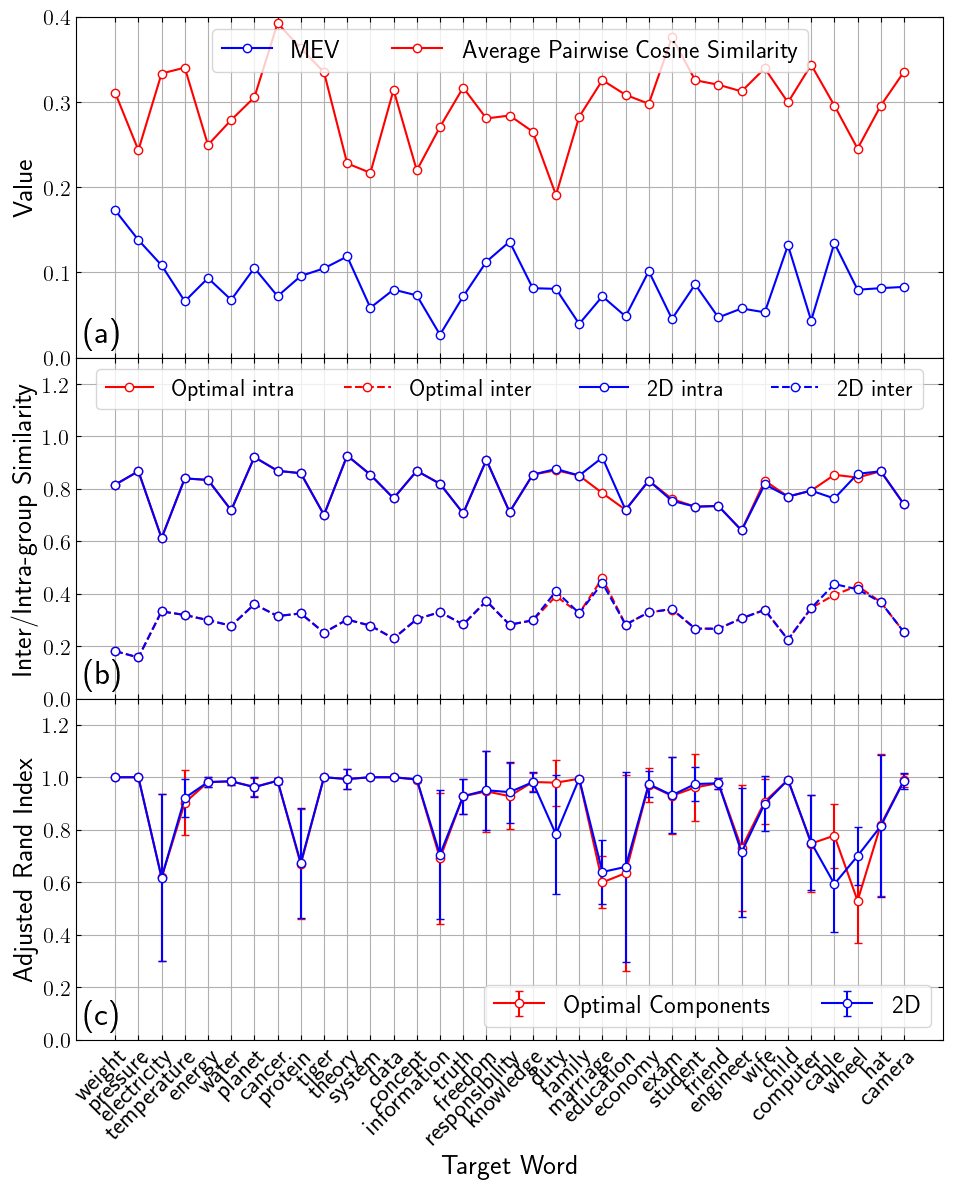

In [ ]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 12), sharex=True)

ax1.errorbar(word_list, average_sims - anisotropic_sim, marker='o', ls='-', c='r', mfc='w', label='Average Pairwise Cosine Similarity', capsize=3,)
ax1.plot(word_list, average_mevs - anisotropic_mev, marker='o', ls='-', c='b', mfc='w', label='MEV')

ax1.set_ylabel('Value', fontsize=20)
ax1.set_xlabel('Target Word', fontsize=20)
ax1.grid()
ax1.set_ylim(0, 0.4)
ax1.legend(loc='upper center', fontsize=18, ncol=2)

intra_similarities_optimal = [experiment_data_all.results_by_word[keyword].intra_similarity_optimal for keyword in word_list]
inter_similarities_optimal = [experiment_data_all.results_by_word[keyword].inter_similarity_optimal for keyword in word_list]

intra_similarities_2D = [experiment_data_all.results_by_word[keyword].intra_similarity_2D for keyword in word_list]
inter_similarities_2D = [experiment_data_all.results_by_word[keyword].inter_similarity_2D for keyword in word_list]

ax2.plot(word_list, intra_similarities_optimal, marker='o', ls='-', c='r', mfc='w', label='Optimal intra')
ax2.plot(word_list, inter_similarities_optimal, marker='o', ls='--', c='r', mfc='w', label='Optimal inter')

ax2.plot(word_list, intra_similarities_2D, marker='o', ls='-', c='b', mfc='w', label='2D intra')
ax2.plot(word_list, inter_similarities_2D, marker='o', ls='--', c='b', mfc='w', label='2D inter')

ax2.set_ylabel('Inter/Intra-group Similarity', fontsize=20)
ax2.set_xlabel('Target Word', fontsize=20)
ax2.grid()
ax2.set_ylim(0, 1.3)
ax2.legend(loc='upper center', fontsize=17, ncol=4)


ax3.errorbar(word_list, aris_optimal, yerr=stds_optimal, c='r', marker='o', mfc='w', label='Optimal Components', capsize=3, zorder=1000)
ax3.errorbar(word_list, aris_2D, yerr=stds_2D, c='b', marker='o', mfc='w', label='2D', capsize=3, zorder=1000)

# ax3.set_xticks(rotation=45, ha='right', rotation_mode='anchor', fontsize=18)
# ax3.set_yticks(fontsize=14)
ax3.set_ylabel('Adjusted Rand Index', fontsize=20)
ax3.set_xlabel('Target Word', fontsize=20)
ax3.grid()
ax3.set_ylim(0, 1.3)
ax3.legend(loc='lower right', fontsize=18, ncol=2)

ax1.tick_params(axis='both', which='major', labelsize=16)
ax2.tick_params(axis='both', which='major', labelsize=16)
ax3.tick_params(axis='both', which='major', labelsize=16)

ax1.text(0.01, 0.12, '(a)', transform=ax1.transAxes, fontsize=24, va='top')
ax2.text(0.01, 0.12, '(b)', transform=ax2.transAxes, fontsize=24, va='top')
ax3.text(0.01, 0.12, '(c)', transform=ax3.transAxes, fontsize=24, va='top')

plt.xticks(rotation=45, ha='right', rotation_mode='anchor', fontsize=18)
plt.tight_layout()
# make the vertical separation between subplots 0
plt.subplots_adjust(hspace=0)
plt.savefig('.assets/imgs/ari_comparison.png', dpi=240)
plt.show()

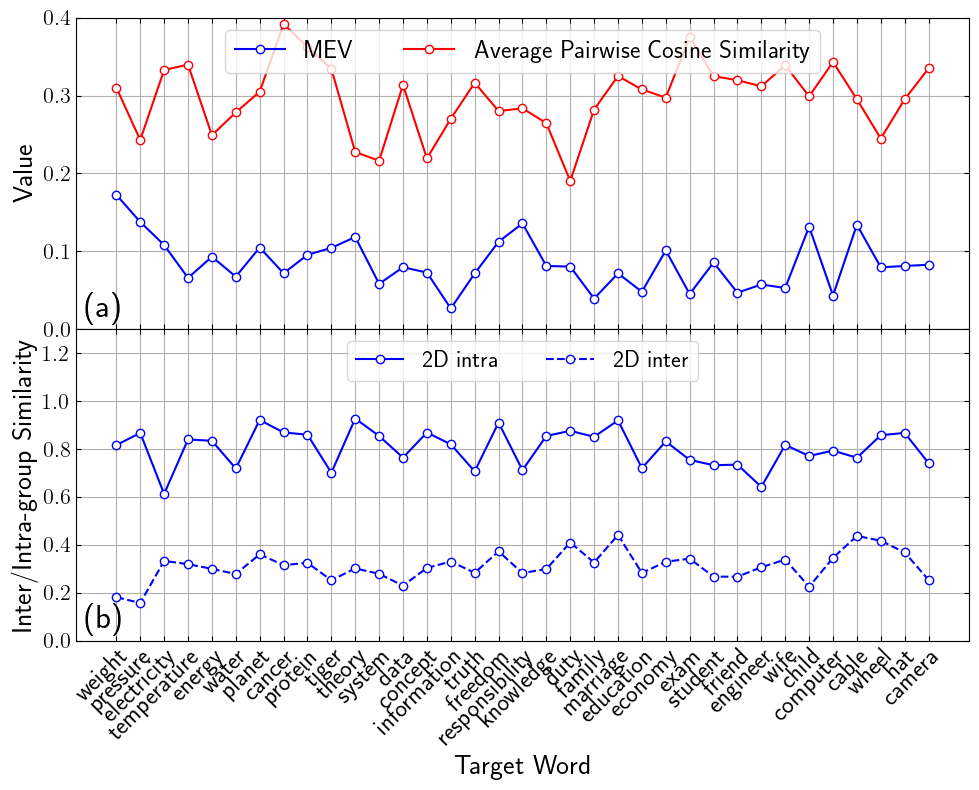

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

ax1.errorbar(word_list, average_sims - anisotropic_sim, marker='o', ls='-', c='r', mfc='w', label='Average Pairwise Cosine Similarity', capsize=3,)
ax1.plot(word_list, average_mevs - anisotropic_mev, marker='o', ls='-', c='b', mfc='w', label='MEV')

ax1.set_ylabel('Value', fontsize=20)
ax1.set_xlabel('Target Word', fontsize=20)
ax1.grid()
ax1.set_ylim(0, 0.4)
ax1.legend(loc='upper center', fontsize=18, ncol=2)

intra_similarities_2D = [experiment_data_all.results_by_word[keyword].intra_similarity_2D for keyword in word_list]
inter_similarities_2D = [experiment_data_all.results_by_word[keyword].inter_similarity_2D for keyword in word_list]

ax2.plot(word_list, intra_similarities_2D, marker='o', ls='-', c='b', mfc='w', label='2D intra')
ax2.plot(word_list, inter_similarities_2D, marker='o', ls='--', c='b', mfc='w', label='2D inter')

ax2.set_ylabel('Inter/Intra-group Similarity', fontsize=20)
ax2.set_xlabel('Target Word', fontsize=20)
ax2.grid()
ax2.set_ylim(0, 1.3)
ax2.legend(loc='upper center', fontsize=17, ncol=2)

ax1.tick_params(axis='both', which='major', labelsize=16)
ax2.tick_params(axis='both', which='major', labelsize=16)

ax1.text(0.01, 0.12, '(a)', transform=ax1.transAxes, fontsize=24, va='top')
ax2.text(0.01, 0.12, '(b)', transform=ax2.transAxes, fontsize=24, va='top')

plt.xticks(rotation=45, ha='right', rotation_mode='anchor', fontsize=18)
plt.tight_layout()
plt.subplots_adjust(hspace=0)
plt.savefig('.assets/imgs/metricsimage.png', dpi=240)
plt.show()

# Download to browser
files.download('.assets/imgs/metricsimage.png')

## Generate Landscapes

This code generates 2D “landscape” visualizations of word embeddings after PCA for a set of target words. For each word, it plots the mean clustering landscape (Zs) as a heatmap with a log-normalized color scale and overlays the PCA points colored by their optimal consensus cluster labels. Figures are created for selected example words and for the full word list in three parts, and all plots are saved as PNG files.

In [ ]:
def plot_landscapes(ax, keyword):
    pca_data = experiment_data_all.results_by_word[keyword].X_pca
    x_min = pca_data[:, 0].min() - 1
    x_max = pca_data[:, 0].max() + 1
    y_min = pca_data[:, 1].min() - 1
    y_max = pca_data[:, 1].max() + 1

    x = np.linspace(x_min, x_max, 100)
    y = np.linspace(y_min, y_max, 100)
    X, Y = np.meshgrid(x, y)

    mean_landscape = np.mean(experiment_data_all.results_by_word[keyword].Zs, axis=0)
    CS = ax.contourf(X, Y, mean_landscape, 100, cmap='hot',norm=LogNorm(vmin=mean_landscape.min(), vmax=mean_landscape.max()), levels=np.logspace(0, 2, 50), alpha=0.5, linewidths=1, zorder=0)

    ax.scatter(experiment_data_all.results_by_word[keyword].X_pca[:, 0], experiment_data_all.results_by_word[keyword].X_pca[:, 1], s=20, c=experiment_data_all.results_by_word[keyword].consensus_labels_optimal, cmap='tab20b')
    ax.set_title(fr'$\textsc{{{keyword}}}$', fontsize=20)
    ax.tick_params(axis='both', which='major', labelsize=16)

<ipython-input-27-c426e91c17ca>:13: UserWarning: linewidths is ignored by contourf
  CS = ax.contourf(X, Y, mean_landscape, 100, cmap='hot',norm=LogNorm(vmin=mean_landscape.min(), vmax=mean_landscape.max()), levels=np.logspace(0, 2, 50), alpha=0.5, linewidths=1, zorder=0)


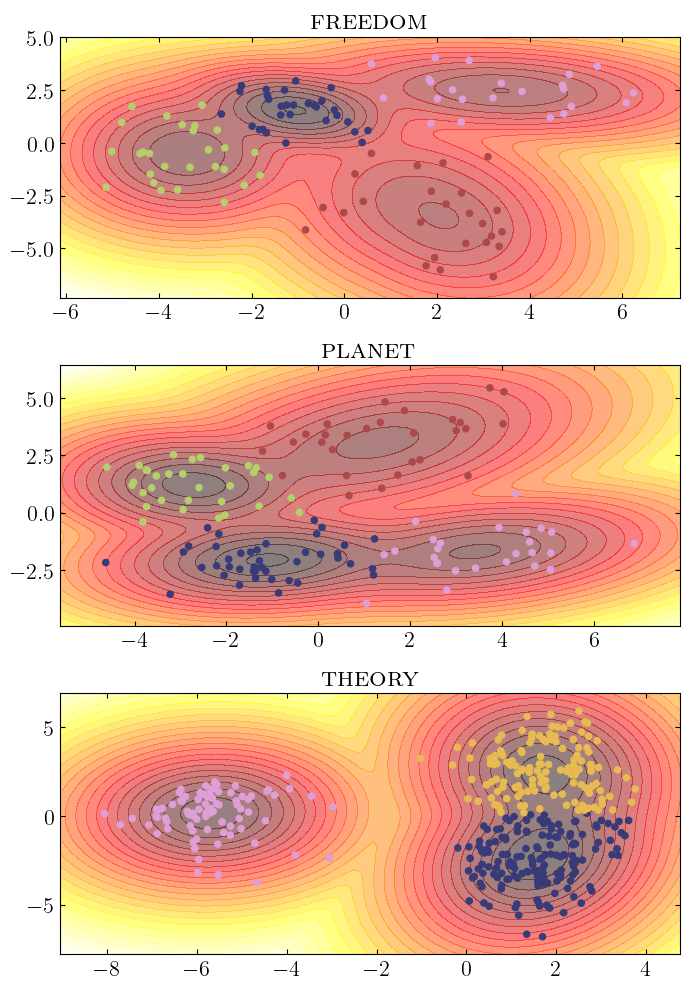

In [ ]:
example_word_list = ['freedom', 'planet', 'theory']

fig, axs = plt.subplots(3, 1, figsize=(7, 10))

for i, keyword in enumerate(example_word_list):
    ax = axs[i]
    plot_landscapes(ax, keyword)

plt.tight_layout()
plt.savefig('imgsconsensus_clustering_example.png', dpi=240)
plt.show()

<ipython-input-27-c426e91c17ca>:13: UserWarning: linewidths is ignored by contourf
  CS = ax.contourf(X, Y, mean_landscape, 100, cmap='hot',norm=LogNorm(vmin=mean_landscape.min(), vmax=mean_landscape.max()), levels=np.logspace(0, 2, 50), alpha=0.5, linewidths=1, zorder=0)


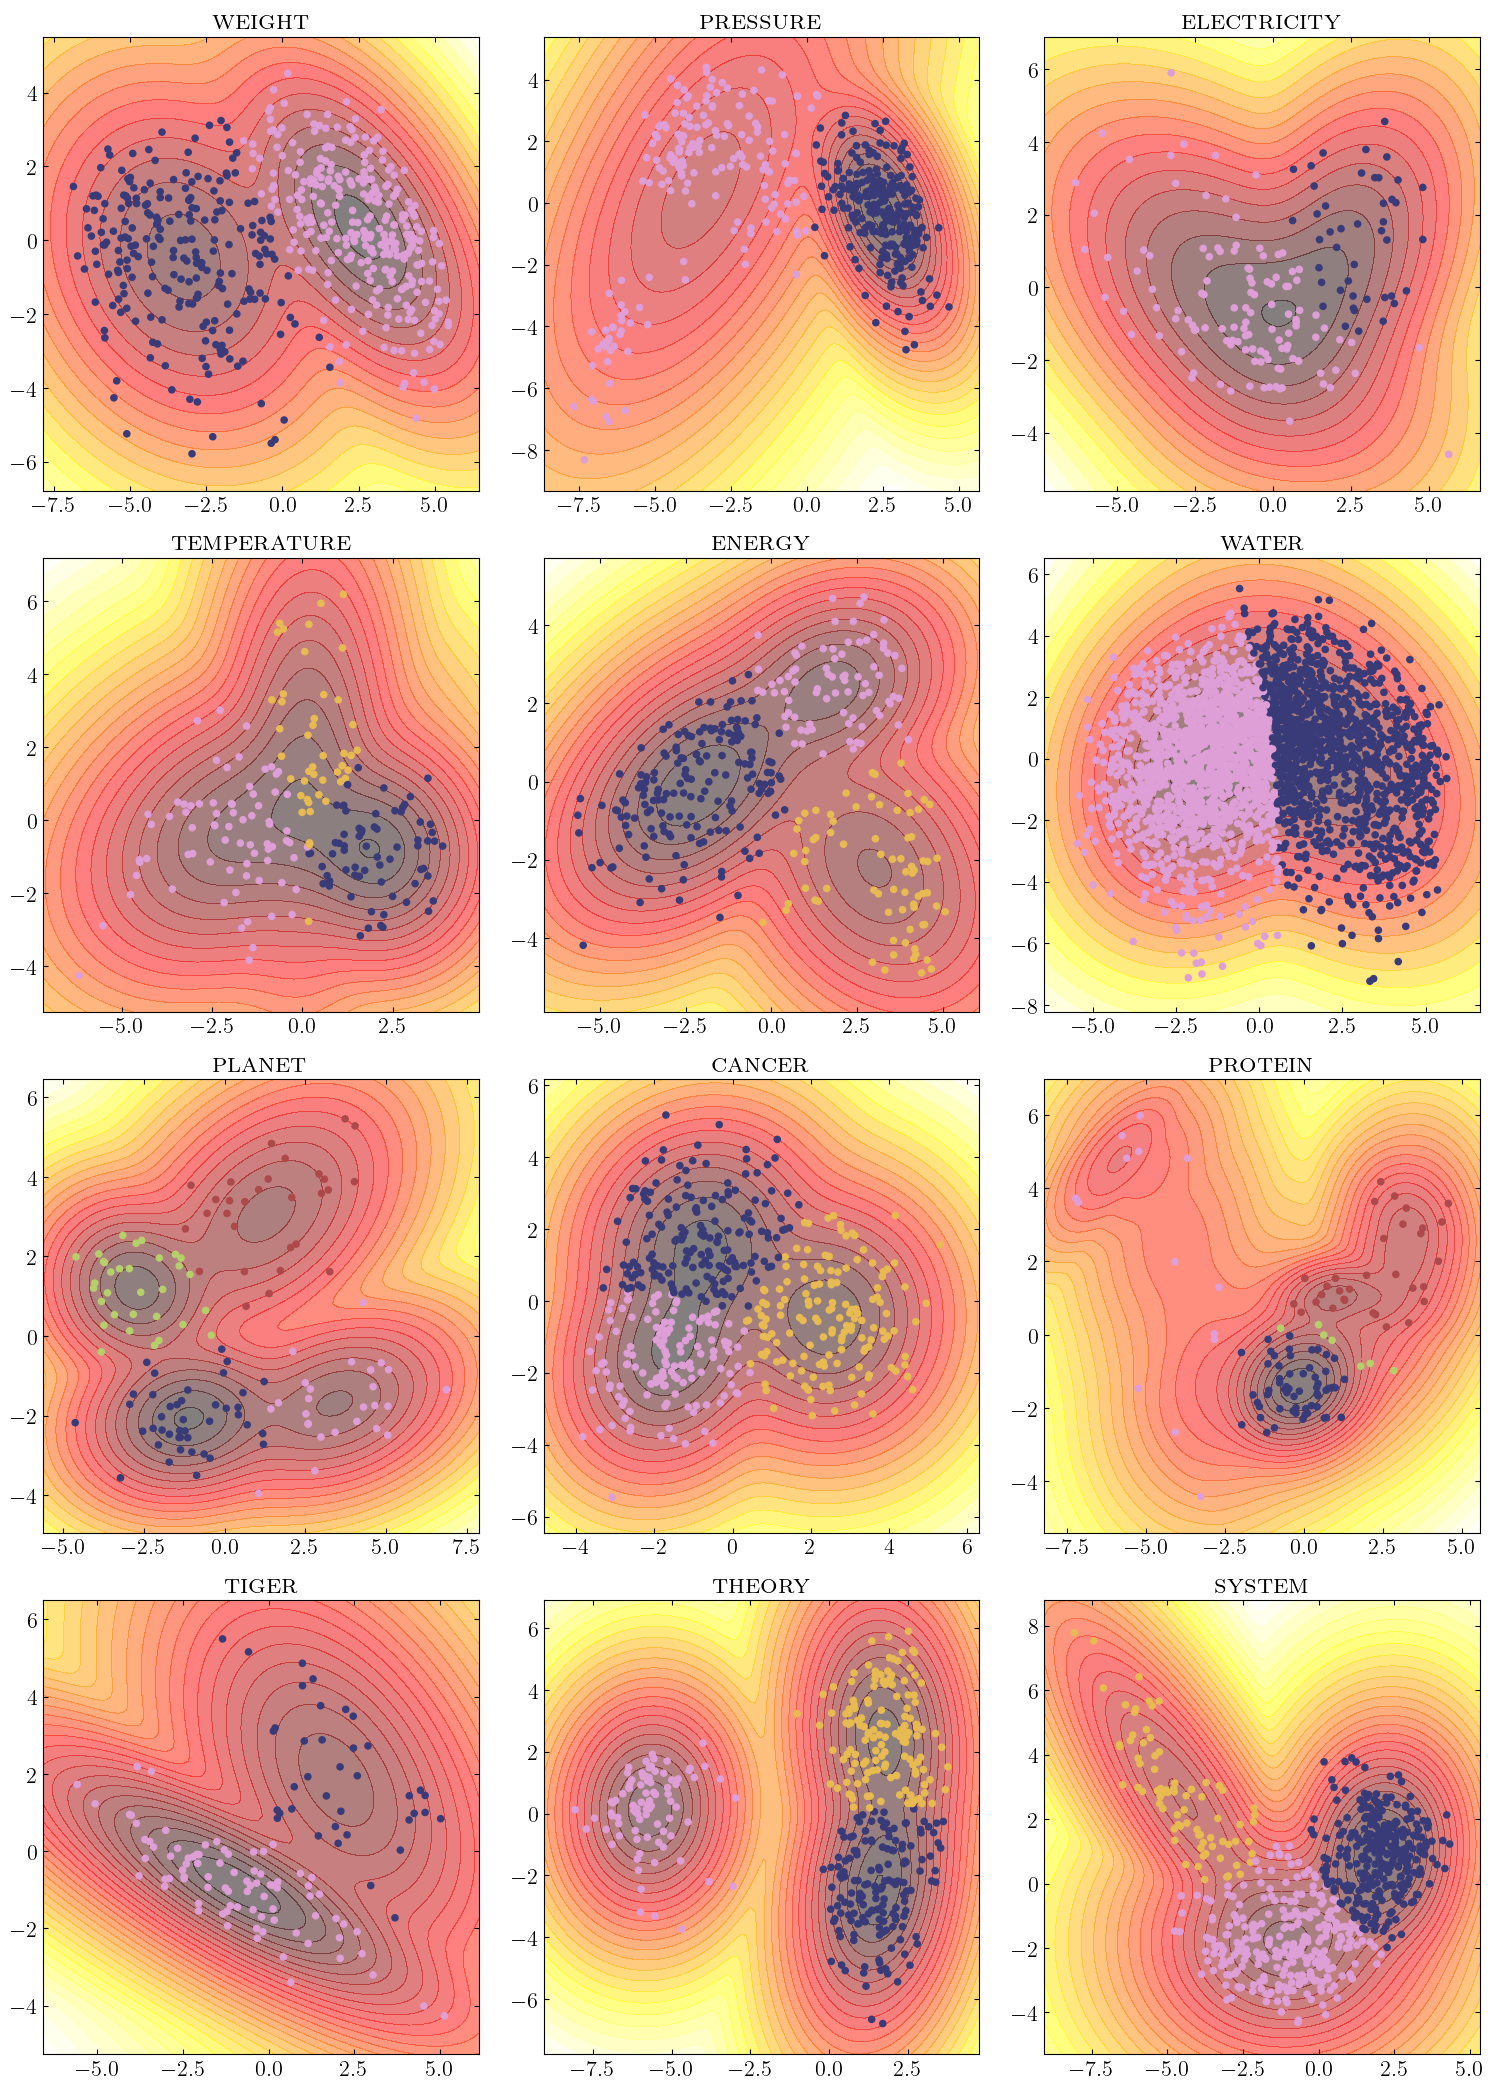

In [ ]:
fig, axs = plt.subplots(4, 3, figsize=(15, 21))

for i, keyword in enumerate(word_list[:12]):
    ax = axs[i // 3, i % 3]
    plot_landscapes(ax, keyword)

plt.tight_layout()
plt.savefig('.consensus_clustering_full_part1.png', dpi=120)
plt.show()

<ipython-input-27-c426e91c17ca>:13: UserWarning: linewidths is ignored by contourf
  CS = ax.contourf(X, Y, mean_landscape, 100, cmap='hot',norm=LogNorm(vmin=mean_landscape.min(), vmax=mean_landscape.max()), levels=np.logspace(0, 2, 50), alpha=0.5, linewidths=1, zorder=0)


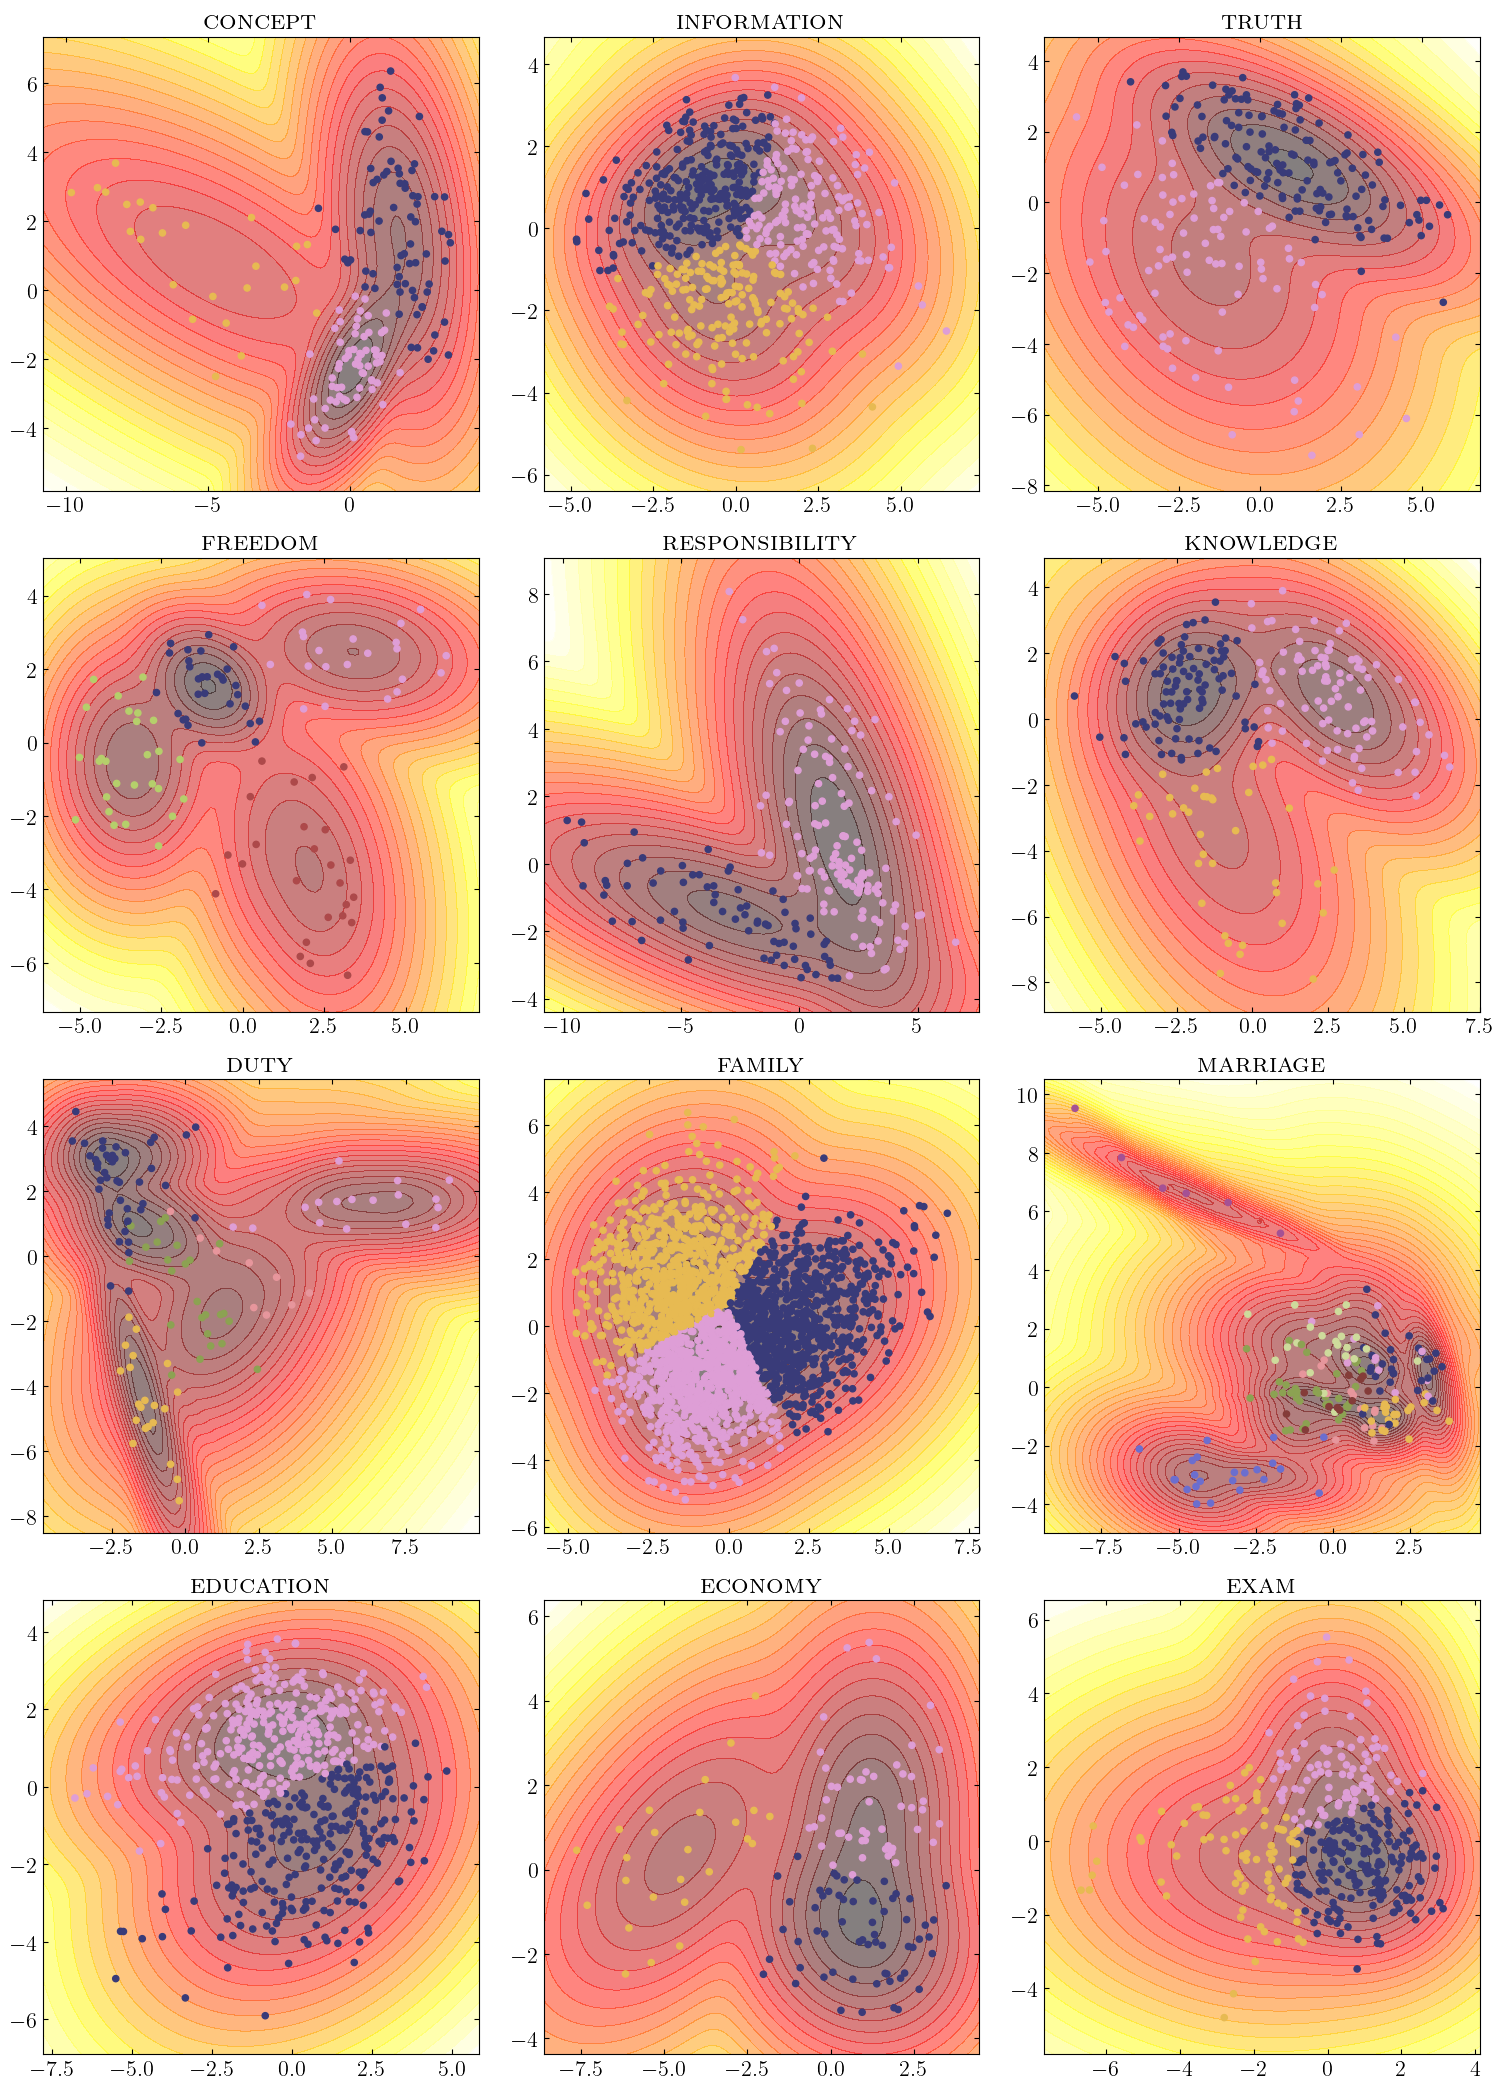

In [ ]:
fig, axs = plt.subplots(4, 3, figsize=(15, 21))

for i, keyword in enumerate(word_list[13:25]):
    ax = axs[i // 3, i % 3]
    plot_landscapes(ax, keyword)

plt.tight_layout()
plt.savefig('.consensus_clustering_full_part2.png', dpi=120)
plt.show()

<ipython-input-27-c426e91c17ca>:13: UserWarning: linewidths is ignored by contourf
  CS = ax.contourf(X, Y, mean_landscape, 100, cmap='hot',norm=LogNorm(vmin=mean_landscape.min(), vmax=mean_landscape.max()), levels=np.logspace(0, 2, 50), alpha=0.5, linewidths=1, zorder=0)


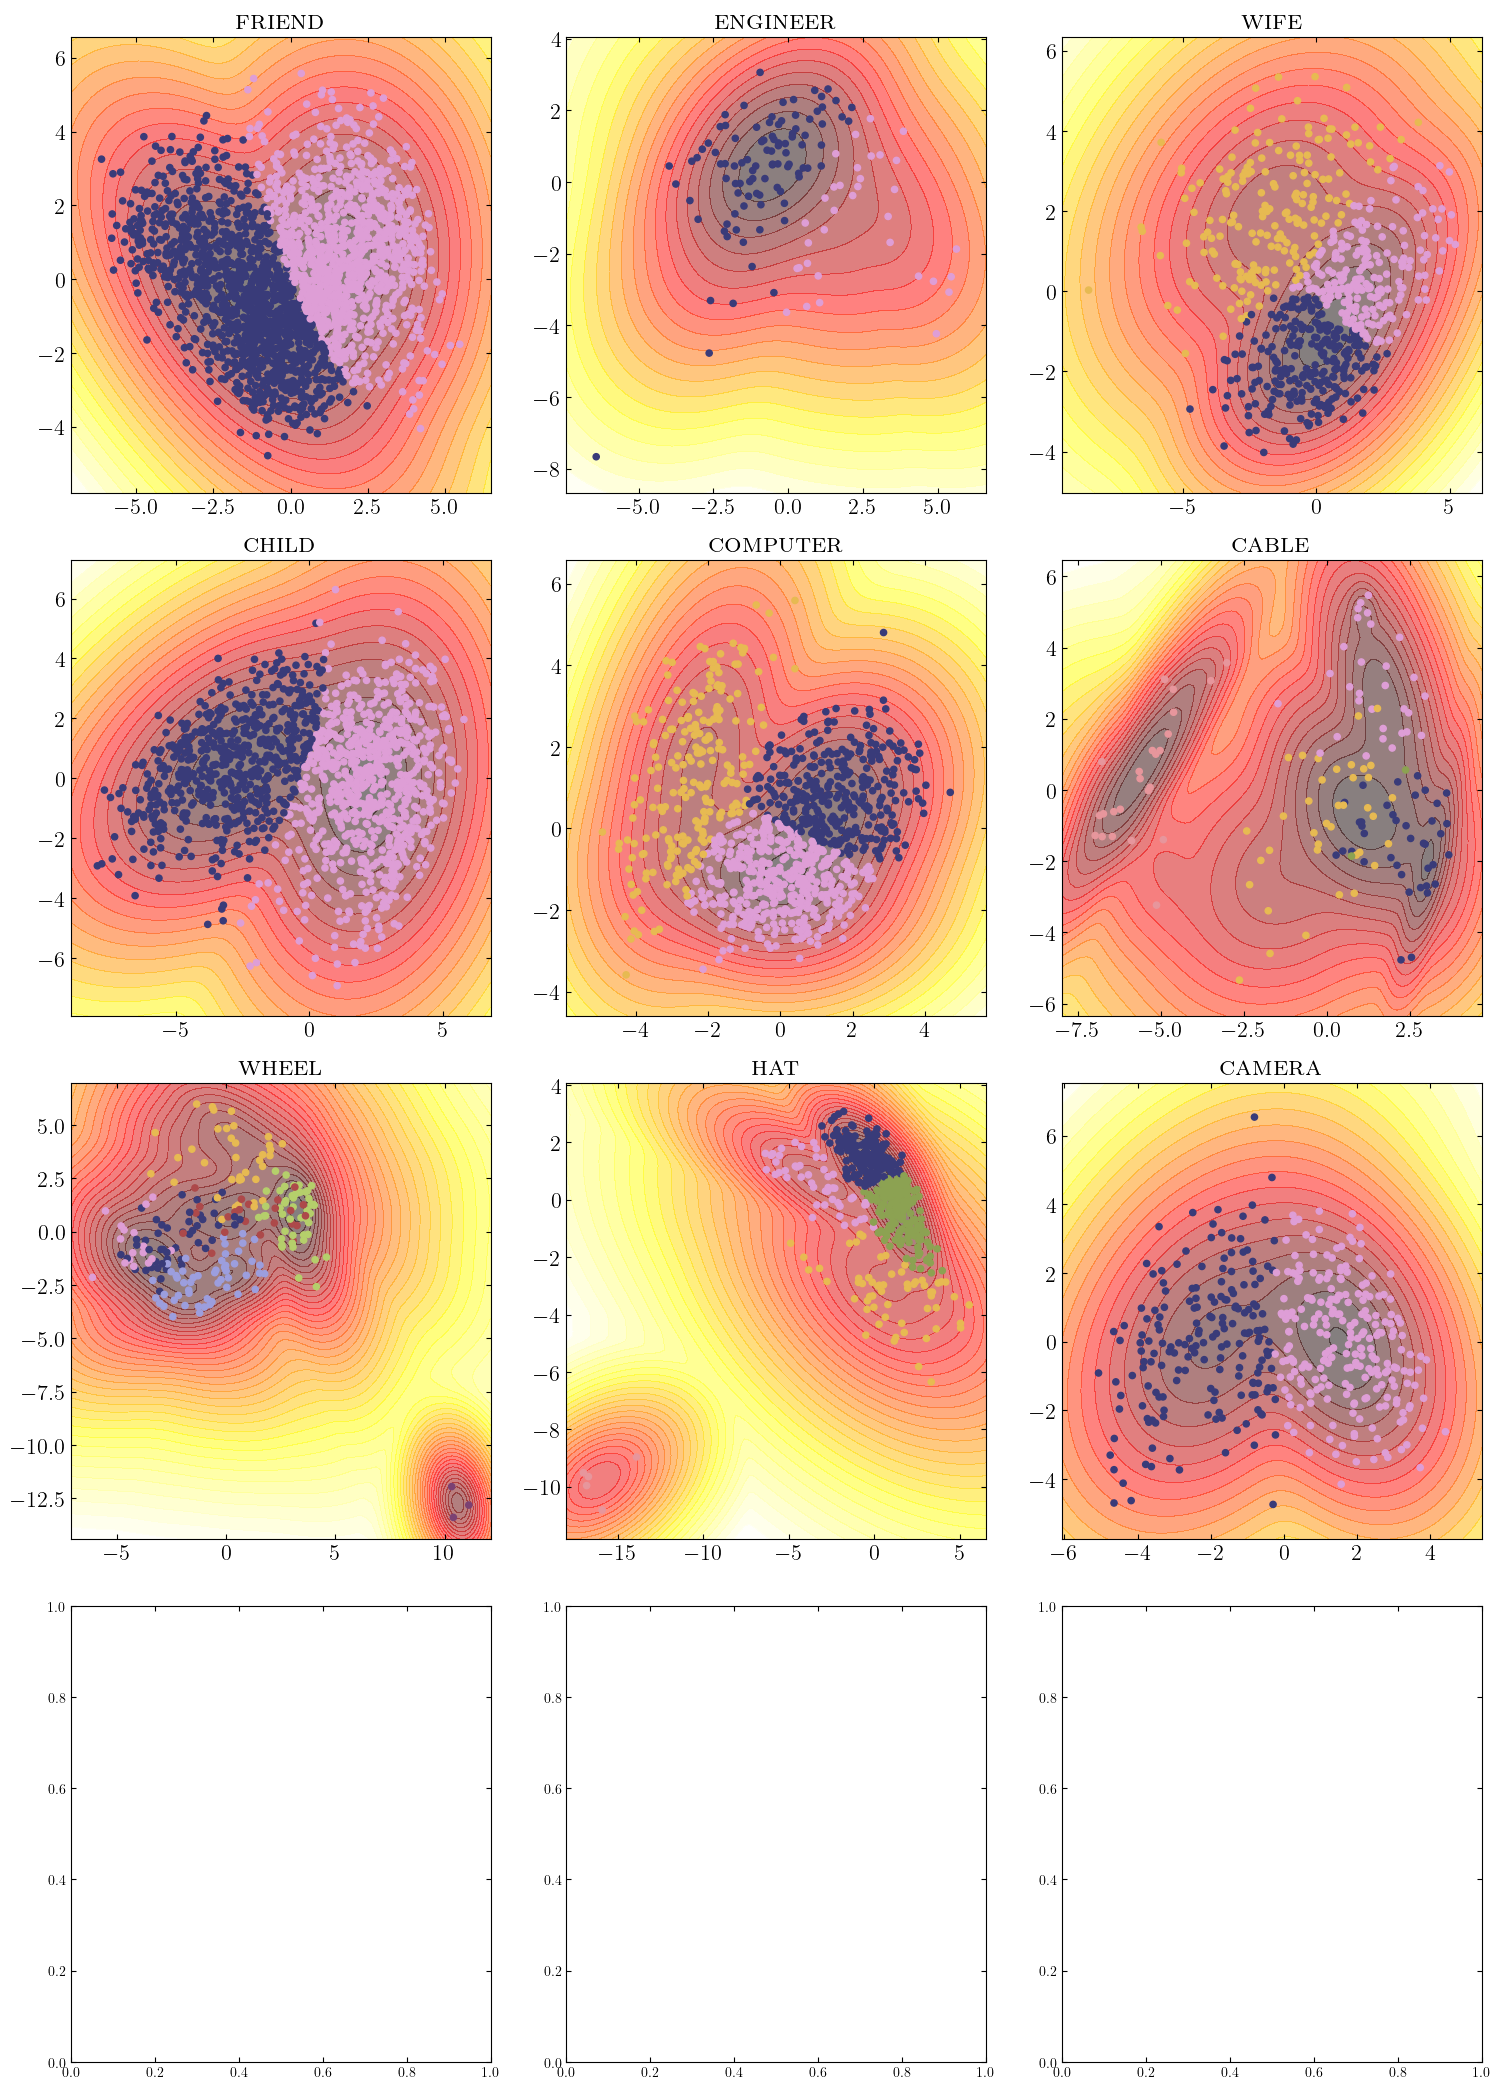

In [ ]:
fig, axs = plt.subplots(4, 3, figsize=(15, 21))

for i, keyword in enumerate(word_list[26:35]):
    ax = axs[i // 3, i % 3]
    plot_landscapes(ax, keyword)

plt.tight_layout()
plt.savefig('.consensus_clustering_full_part3.png', dpi=120)
plt.show()

## Produce cluster texts for all words

This code generates and saves text files containing all context sentences for each target word, grouped by their optimal consensus cluster. Each file lists clusters and the corresponding contexts, making it easy to inspect which contexts were assigned to each cluster.

In [ ]:
for word in word_list:

    output_file_path = f'./experiments/context_groups/cluster_contexts_{word}.txt'

    # Get the existing cluster labels
    labels = experiment_data_all.results_by_word[word].consensus_labels_optimal
    contexts = experiment_data_all.results_by_word[word].contexts

    # Open the file for writing
    with open(output_file_path, 'w') as file:
        # Print every context per cluster
        for label in np.unique(labels):
            file.write(f"Cluster {label}\n")
            indices = np.where(labels == label)[0]
            for idx in indices:
                original_number = idx
                file.write(f"{original_number}. {contexts[idx]}\n")
            file.write('\n')

    # Print confirmation message
    print(f"Cluster contexts saved to {output_file_path}")

Cluster contexts saved to ./experiments/context_groups/cluster_contexts_weight.txt
Cluster contexts saved to ./experiments/context_groups/cluster_contexts_pressure.txt
Cluster contexts saved to ./experiments/context_groups/cluster_contexts_electricity.txt
Cluster contexts saved to ./experiments/context_groups/cluster_contexts_temperature.txt
Cluster contexts saved to ./experiments/context_groups/cluster_contexts_energy.txt
Cluster contexts saved to ./experiments/context_groups/cluster_contexts_water.txt
Cluster contexts saved to ./experiments/context_groups/cluster_contexts_planet.txt
Cluster contexts saved to ./experiments/context_groups/cluster_contexts_cancer.txt
Cluster contexts saved to ./experiments/context_groups/cluster_contexts_protein.txt
Cluster contexts saved to ./experiments/context_groups/cluster_contexts_tiger.txt
Cluster contexts saved to ./experiments/context_groups/cluster_contexts_theory.txt
Cluster contexts saved to ./experiments/context_groups/cluster_contexts_syst

## Compare labels and context numbers to a plot

Visualize PCA embeddings and consensus clusters for target words, saving plots and coordinates for analysis.

In [ ]:
for word in word_list:

    output_folder =  '.experiments'
    folder_path = os.path.join(output_folder, word)

    if not os.path.exists(folder_path):
        os.makedirs(folder_path)

    plt.figure(figsize=(10, 8))

    X_pca = experiment_data_all.results_by_word[word].X_pca
    labels = experiment_data_all.results_by_word[word].consensus_labels_optimal

    plt.title(f"PCA Projection of '{word}' Embeddings")
    plt.xlabel("Principal Component 1")
    plt.ylabel("Principal Component 2")

    plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='Pastel2', s=50)

    for j, (x, y) in enumerate(X_pca[:,:2]):
        plt.text(x, y, str(j), fontsize=10, ha='center', va='center')


    plt.savefig(os.path.join(folder_path, f'pca_{word}.png'))
    plt.close('all')


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import os

# Define color map for labels (with maximally different colors for readability)
label_colors = ['yellow', 'red', 'blue', 'green', 'purple', 'orange', 'brown', 'pink', 'cyan', 'magenta', 'yellow']

# Define marker styles for different clusters
markers = ['D', 'o', 'x', '*', 's', '^', 'v', '<', '>', '+']

for word in word_list:
    output_folder = '.experiments_img'
    folder_path = os.path.join(output_folder, word)

    if not os.path.exists(folder_path):
        os.makedirs(folder_path)

    plt.figure(figsize=(10, 8))

    X_pca = experiment_data_all.results_by_word[word].X_pca
    labels = experiment_data_all.results_by_word[word].consensus_labels_optimal

    plt.title(f"PCA Projection of '{word}' Embeddings", fontsize=18)
    plt.xlabel("Principal Component 1", fontsize=16)
    plt.ylabel("Principal Component 2", fontsize=16)

    # Create a scatter plot for each cluster to ensure all are represented in the legend
    for i in range(len(label_colors)):
        # Select data points belonging to the current cluster
        cluster_points = X_pca[labels == i]
        if cluster_points.size > 0:
            plt.scatter(cluster_points[:, 0], cluster_points[:, 1], c=[label_colors[i]], marker=markers[i], s=60, label=f'Cluster {i}')

    # Add the legend to the plot
    plt.legend(title="Clusters")

    # Save the figure with the legend
    plt.savefig(os.path.join(folder_path, f'pca_{word}.png'))
    plt.close('all')


In [ ]:
import os

output_folder = '.experiments'

# Loop through each word and save the coordinates in a .txt file
for word in word_list:
    folder_path = os.path.join(output_folder, word)
    X_pca = experiment_data_all.results_by_word[word].X_pca

    # Define the file path for saving coordinates
    coordinates_file_path = os.path.join(folder_path, f'pca_coordinates_{word}.txt')

    # Write coordinates to a text file
    with open(coordinates_file_path, 'w') as file:
        for j, (x, y) in enumerate(X_pca[:, :2]):
            file.write(f"Point {j}: ({x:.3f}, {y:.3f})\n")


Compile clustering, PCA, similarity, and ARI metrics for all target words into a CSV summary with an added lexical taxonomy column for analysis.

In [ ]:
import pandas as pd

# pandas dataframe with columns: word, optimal components, optimal clusters, cosine sim, mev, ari, ari std, intra sim, inter sim

data = []

for i, keyword in enumerate(word_list):
    data.append([keyword, results[keyword][40]['best_params']['n_components'],
                results[keyword][40]['best_params']['n_clusters'],
                results[keyword][40]['best_score'],
                average_sims[i] - anisotropic_sim,
                average_mevs[i] - anisotropic_mev,
                experiment_data_all.results_by_word[keyword].ari_mean_optimal,
                experiment_data_all.results_by_word[keyword].ari_std_optimal,
                experiment_data_all.results_by_word[keyword].ari_mean_2D,
                experiment_data_all.results_by_word[keyword].ari_std_2D,
                experiment_data_all.results_by_word[keyword].intra_similarity_optimal,
                experiment_data_all.results_by_word[keyword].inter_similarity_optimal,
                experiment_data_all.results_by_word[keyword].intra_similarity_2D,
                experiment_data_all.results_by_word[keyword].inter_similarity_2D
                ])

df = pd.DataFrame(data, columns=['word',
                                      'optimal components',
                                      'optimal clusters',
                                      'best_score',
                                      'cosine sim',
                                      'mev',
                                      'optimal ari',
                                      'optimal ari std',
                                      '2D ari',
                                      '2D ari std',
                                      'optimal intra sim',
                                      'optimal inter sim',
                                      '2D intra sim',
                                      '2D inter sim'])

# Create the taxonomy column
taxonomy_values = [(i // 5) + 1 for i in range(len(df))]
df.insert(0, 'taxonomy', taxonomy_values)

df.head(35)


,taxonomy,word,optimal components,optimal clusters,best_score,cosine sim,mev,optimal ari,optimal ari std,2D ari,2D ari std,optimal intra sim,optimal inter sim,2D intra sim,2D inter sim
0,1,weight,2,2,0.750652,0.310679,0.172818,1.000000,0.000000,1.000000,0.000000,0.815603,0.181045,0.815603,0.181045
1,1,pressure,2,2,0.821237,0.243404,0.138007,1.000000,0.000000,1.000000,0.000000,0.866782,0.156681,0.866782,0.156681
2,1,electricity,2,2,0.539896,0.333327,0.108330,0.618092,0.318814,0.616866,0.317629,0.611861,0.332506,0.611861,0.332506
3,1,temperature,2,3,0.636612,0.340218,0.066126,0.903176,0.123609,0.921066,0.074091,0.839512,0.318740,0.839512,0.318740
4,1,energy,2,3,0.685550,0.249544,0.093338,0.981313,0.019879,0.981695,0.019819,0.833687,0.299177,0.833687,0.299177
5,2,water,2,2,0.585281,0.278827,0.067784,0.984613,0.013536,0.984560,0.013697,0.718104,0.277732,0.718104,0.277732
6,2,planet,2,4,0.712814,0.305397,0.105161,0.963082,0.032944,0.962161,0.038951,0.920761,0.359755,0.920761,0.359755
7,2,cancer,2,3,0.695343,0.392293,0.072063,0.986723,0.011790,0.986533,0.011809,0.868407,0.314688,0.868407,0.314688
8,2,protein,2,4,0.512565,0.363107,0.095753,0.668135,0.210080,0.673554,0.211043,0.859309,0.324549,0.859309,0.324549
9,2,tiger,2,2,0.591279,0.334866,0.104705,1.000000,0.000000,1.000000,0.000000,0.700272,0.251427,0.700273,0.251427


In [ ]:
save_path = './experiments/summary_table.csv'

df.to_csv(save_path)